# Poisoning Budget Analysis (Intermediate)

This notebook studies **how the proportion of poisoned training data** affects classifier performance under a **white-box, training-time label-flipping** attack on two text-based tasks:

1. **Binary classification** — Enron spam detection  
2. **Multi-class classification** — MURLs malware domain classification

---

## Theoretical framework

### Attack model: random label-flipping

The attacker does **not** modify features $(X)$. They only corrupt a subset of training labels $(y)$ in the pristine training set. This is a classic **availability / reliability** poisoning pattern: the model is trained on misleading supervision while inputs remain realistic.

### Cost budget \(C\)

$(C \in [0, 1])$ is the **maximum fraction of training points** the attacker may relabel. For example, $(C = 0.10)$ means at most 10% of training labels are flipped. Larger $(C)$ means a more expensive attack (more annotations corrupted).

### Attacker goal: reliability attack

The objective is to **maximize prediction error on clean test data** — i.e., degrade generalization on held-out, unmodified examples. I therefore keep the **test set completely clean** and only poison **training** labels.



## Step 1: Setup and data loading


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Reproducibility
RANDOM_STATE = 40
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
ENRON_CSV = DATA_DIR / "enron_spam.csv"
MURLs_CSV = DATA_DIR / "malicious_phish.csv"

POISONING_BUDGETS = [0.0, 0.01, 0.05, 0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
MAX_TFIDF_FEATURES = 5000
TEST_SIZE = 0.20

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

In [16]:
import os
import zipfile
import pandas as pd
from pathlib import Path
import kaggle

ENRON_KAGGLE_DATASET  = "marcelwiechmann/enron-spam-data"
MURLs_KAGGLE_DATASET = "sid321axn/malicious-urls-dataset"     
ENRON_CSV_NAME  = "enron_spam_data.csv"   
MURLs_CSV_NAME = "malicious_phish.csv"    

DATA_DIR = Path("data")


def _download_kaggle_dataset(dataset_slug: str, dest_dir: Path) -> None:
    dest_dir.mkdir(parents=True, exist_ok=True)
    print(f"[Kaggle] Downloading '{dataset_slug}' → {dest_dir}")
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files(dataset_slug, path=str(dest_dir), unzip=True, quiet=False)

def _ensure_csv(dataset_slug: str, csv_name: str, dest_dir: Path) -> Path:
    """Return the path to *csv_name*, downloading the dataset first if needed."""
    csv_path = dest_dir / csv_name
    if not csv_path.exists():
        _download_kaggle_dataset(dataset_slug, dest_dir)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Expected '{csv_name}' inside dataset '{dataset_slug}', "
            f"but it was not found in {dest_dir}. "
            "Check the filename constant at the top of this file."
        )
    return csv_path


def _load_csv(csv_path: Path, dataset_name: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    # ── Enron: combine Subject + Message into a single text field ────
    if "Subject" in df.columns and "Message" in df.columns:
        df["text"] = df["Subject"].fillna("") + " " + df["Message"].fillna("")
        df["label"] = df["Spam/Ham"]

    # ── Malicious URLs dataset ─────
    if "url" in df.columns:
        df = df.rename(columns={"url": "text", "type": "label"})

    required = {"text", "label"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(
            f"{dataset_name} CSV is missing columns {missing}. "
            f"Actual columns: {df.columns.tolist()}"
        )

    return df[["text", "label"]].dropna().reset_index(drop=True)

# ── Public loaders ───

def load_enron_dataset(
    csv_name: str = ENRON_CSV_NAME,
    dataset_slug: str = ENRON_KAGGLE_DATASET,
    dest_dir: Path = DATA_DIR / "enron",
) -> pd.DataFrame:
    """Download (if necessary) and load the Enron spam dataset from Kaggle."""
    csv_path = _ensure_csv(dataset_slug, csv_name, dest_dir)
    return _load_csv(csv_path, "Enron")


def load_murls_dataset(
    csv_name: str = MURLs_CSV_NAME,
    dataset_slug: str = MURLs_KAGGLE_DATASET,
    dest_dir: Path = DATA_DIR / "murls",
) -> pd.DataFrame:
    """Download (if necessary) and load the Malicious URLs dataset from Kaggle."""
    csv_path = _ensure_csv(dataset_slug, csv_name, dest_dir)
    return _load_csv(csv_path, "MURLs")

In [17]:
df_enron = load_enron_dataset()
df_murls = load_murls_dataset()

print("Enron shape:", df_enron.shape)
print("MURLs shape:", df_murls.shape)
print(df_murls.head())

Enron shape: (33716, 2)
MURLs shape: (651191, 2)
                                                text       label
0                                   br-icloud.com.br    phishing
1                mp3raid.com/music/krizz_kaliko.html      benign
2                    bopsecrets.org/rexroth/cr/1.htm      benign
3  http://www.garage-pirenne.be/index.php?option=...  defacement
4  http://adventure-nicaragua.net/index.php?optio...  defacement


In [18]:
# Inspect the full folder structure
import os
for root, dirs, files in os.walk("data/MURLs"):
    level = root.replace("data/MURLs", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for file in files[:5]:  # show only first 5 files per folder to avoid spam
        print(f"{subindent}{file}")
    if len(files) > 5:
        print(f"{subindent}... and {len(files) - 5} more files")

MURLs/
  malicious_phish.csv


In [19]:
# Run this to inspect the real column names
import pandas as pd
from pathlib import Path

df_raw = pd.read_csv("data/enron/enron_spam_data.csv")
print(df_raw.columns.tolist())
print(df_raw.head(3))

['Unnamed: 0', 'Subject', 'Message', 'Spam/Ham', 'Date']
   Unnamed: 0                       Subject  \
0           0  christmas tree farm pictures   
1           1      vastar resources , inc .   
2           2  calpine daily gas nomination   

                                             Message Spam/Ham        Date  
0                                                NaN      ham  1999-12-10  
1  gary , production from the high island larger ...      ham  1999-12-13  
2             - calpine daily gas nomination 1 . doc      ham  1999-12-14  


In [20]:
import os
print(os.listdir("data/enron"))
print(os.listdir("data/MURLs"))

['build_data_file.py', 'enron_spam_data.csv', 'LICENSE', 'README.md']
['malicious_phish.csv']


## Step 2: Preprocessing and feature extraction

Text is converted with **TF–IDF** (`max_features=5000` for speed). I use an **80/20 train–test split**. The **test labels and features are never poisoned** — they are the ground truth for measuring attacker utility (degradation on clean data).

In [ ]:
def preprocess_and_vectorize(
    df: pd.DataFrame,
    max_features: int = MAX_TFIDF_FEATURES,
    test_size: float = TEST_SIZE,
    random_state: int = RANDOM_STATE,
):
    #TF-IDF features, label encoding, and stratified train/test split.
    texts = df["text"].astype(str)
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df["label"])
    num_classes = len(label_encoder.classes_)

    vectorizer = TfidfVectorizer(max_features=max_features)
    X = vectorizer.fit_transform(texts)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )
    return X_train, X_test, y_train, y_test, num_classes, label_encoder

## Step 3: Poisoning logic (label flipping)

Given budget $(C)$, I uniformly sample $(\lfloor C \cdot n \rfloor)$ training indices (at least one when $(C > 0)$ and $(n \geq 1))$ and flip their labels:

- **Binary:** $(0 \leftrightarrow 1)$  
- **Multi-class:** replace with a **uniformly random incorrect** class

Features $(X_{\text{train}})$ are unchanged — only $(y_{\text{train}})$ is corrupted, respecting the budget constraint.

In [22]:
def apply_label_flipping(
    y_train: np.ndarray,
    budget: float,
    num_classes: int,
    random_state: int = RANDOM_STATE,
) -> np.ndarray:
    y_poisoned = np.array(y_train, copy=True)
    n = len(y_poisoned)
    if budget <= 0 or n == 0:
        return y_poisoned

    n_poison = int(np.floor(budget * n))
    if n_poison < 1:
        n_poison = 1
    n_poison = min(n_poison, n)

    rng = np.random.default_rng(random_state)
    poison_indices = rng.choice(n, size=n_poison, replace=False)

    for idx in poison_indices:
        original = y_poisoned[idx]
        if num_classes == 2:
            y_poisoned[idx] = 1 - original
        else:
            candidates = [c for c in range(num_classes) if c != original]
            y_poisoned[idx] = rng.choice(candidates)

    return y_poisoned

## Step 4: Experimental loop

For each dataset and each budget $(C \in \{0, 1\%, 5\%, \ldots, 30\%\})$:

1. Flip labels on the training set only.  
2. Retrain **Logistic Regression** (fast linear baseline on sparse TF–IDF).  
3. Evaluate on the **clean test set**.  
4. Record Accuracy, Precision, Recall, and F1 (macro for multi-class).

Rising $(C)$ should monotonically stress the model under a reliability attack, manifesting as loIr attacker-facing utility (worse metrics for the defender).

In [23]:
def build_classifier(random_state: int = RANDOM_STATE) -> LogisticRegression:
    """Fast linear baseline for sparse TF-IDF features."""
    return LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        random_state=random_state,
    )


def evaluate_on_clean_test(
    y_test: np.ndarray,
    y_pred: np.ndarray,
    average: str,
) -> dict:
    """Compute standard metrics on unpoisoned test labels."""
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average=average, zero_division=0),
        "recall": recall_score(y_test, y_pred, average=average, zero_division=0),
        "f1": f1_score(y_test, y_pred, average=average, zero_division=0),
    }


def run_poisoning_experiment(
    X_train,
    X_test,
    y_train: np.ndarray,
    y_test: np.ndarray,
    num_classes: int,
    dataset_name: str,
    budgets: list = None,
    metric_average: str = "binary",
) -> pd.DataFrame:
    """SIep poisoning budgets; return one row per (budget, metric)."""
    if budgets is None:
        budgets = POISONING_BUDGETS

    rows = []
    for budget in budgets:
        y_train_poisoned = apply_label_flipping(
            y_train, budget=budget, num_classes=num_classes
        )
        clf = build_classifier()
        clf.fit(X_train, y_train_poisoned)
        y_pred = clf.predict(X_test)
        scores = evaluate_on_clean_test(y_test, y_pred, average=metric_average)

        for metric_name, value in scores.items():
            rows.append(
                {
                    "dataset": dataset_name,
                    "budget": budget,
                    "budget_pct": budget * 100,
                    "metric": metric_name,
                    "score": value,
                }
            )
    return pd.DataFrame(rows)

### Run: Enron (binary) and MURLs (multi-class)

In [25]:
enron_df = load_enron_dataset()
MURLs_df = load_murls_dataset()

print(f"Enron samples: {len(enron_df):,} | classes: {enron_df['label'].nunique()}")
print(f"MURLs samples: {len(MURLs_df):,} | classes: {MURLs_df['label'].nunique()}")

Enron samples: 33,716 | classes: 2
MURLs samples: 651,191 | classes: 4


In [26]:
X_train_e, X_test_e, y_train_e, y_test_e, n_classes_e, _ = preprocess_and_vectorize(enron_df)
X_train_u, X_test_u, y_train_u, y_test_u, n_classes_u, le_u = preprocess_and_vectorize(MURLs_df)

results_enron = run_poisoning_experiment(
    X_train_e,
    X_test_e,
    y_train_e,
    y_test_e,
    num_classes=n_classes_e,
    dataset_name="Enron (Binary)",
    metric_average="binary",
)

results_MURLs = run_poisoning_experiment(
    X_train_u,
    X_test_u,
    y_train_u,
    y_test_u,
    num_classes=n_classes_u,
    dataset_name="MURLs (Multi-Class)",
    metric_average="macro",
)

results_all = pd.concat([results_enron, results_MURLs], ignore_index=True)
results_all

,dataset,budget,budget_pct,metric,score
0,Enron (Binary),0.00,0.0,accuracy,0.999407
1,Enron (Binary),0.00,0.0,precision,0.998837
2,Enron (Binary),0.00,0.0,recall,1.000000
3,Enron (Binary),0.00,0.0,f1,0.999418
4,Enron (Binary),0.01,1.0,accuracy,0.999407
5,Enron (Binary),0.01,1.0,precision,0.998837
6,Enron (Binary),0.01,1.0,recall,1.000000
7,Enron (Binary),0.01,1.0,f1,0.999418
8,Enron (Binary),0.05,5.0,accuracy,0.999407
9,Enron (Binary),0.05,5.0,precision,0.998837


## Step 5: Evaluation and visualization

Pivot tables summarize attacker utility: as **Poisoning Budget (%)** grows, metric scores on the **clean test set** should fall, indicating a successful reliability attack within budget $(C)$.

In [27]:
def results_to_wide(df: pd.DataFrame) -> pd.DataFrame:
    """Wide table: one row per budget, columns per metric."""
    wide = df.pivot_table(
        index=["dataset", "budget_pct"],
        columns="metric",
        values="score",
    ).reset_index()
    wide.columns.name = None
    return wide.sort_values("budget_pct")


print("=== Enron (Binary) ===")
display(results_to_wide(results_enron))

print("\n=== MURLs (Multi-Class) ===")
display(results_to_wide(results_MURLs))

=== Enron (Binary) ===


,dataset,budget_pct,accuracy,f1,precision,recall
0,Enron (Binary),0.0,0.999407,0.999418,0.998837,1.0
1,Enron (Binary),1.0,0.999407,0.999418,0.998837,1.0
2,Enron (Binary),5.0,0.999407,0.999418,0.998837,1.0
3,Enron (Binary),10.0,0.999407,0.999418,0.998837,1.0
4,Enron (Binary),15.0,0.999407,0.999418,0.998837,1.0
5,Enron (Binary),20.0,0.998962,0.998982,0.997966,1.0
6,Enron (Binary),30.0,0.989472,0.989771,0.979749,1.0



=== MURLs (Multi-Class) ===


,dataset,budget_pct,accuracy,f1,precision,recall
0,MURLs (Multi-Class),0.0,0.934528,0.910509,0.937050,0.890725
1,MURLs (Multi-Class),1.0,0.933722,0.908830,0.936399,0.888826
2,MURLs (Multi-Class),5.0,0.930128,0.903375,0.932185,0.882456
3,MURLs (Multi-Class),10.0,0.928017,0.899718,0.930070,0.877918
4,MURLs (Multi-Class),15.0,0.926197,0.896765,0.927936,0.874529
5,MURLs (Multi-Class),20.0,0.924316,0.893470,0.925327,0.871130
6,MURLs (Multi-Class),30.0,0.920999,0.888611,0.923089,0.864523


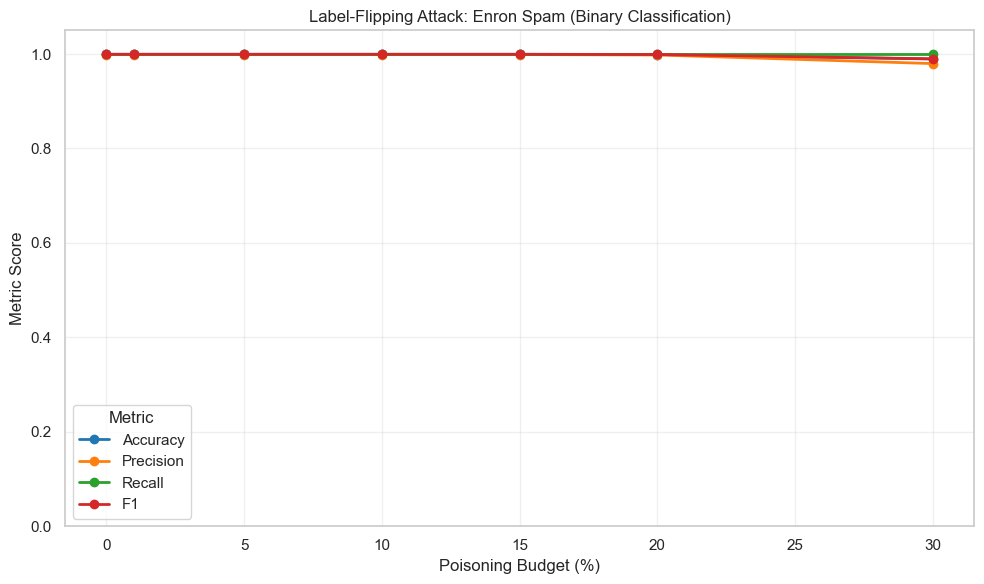

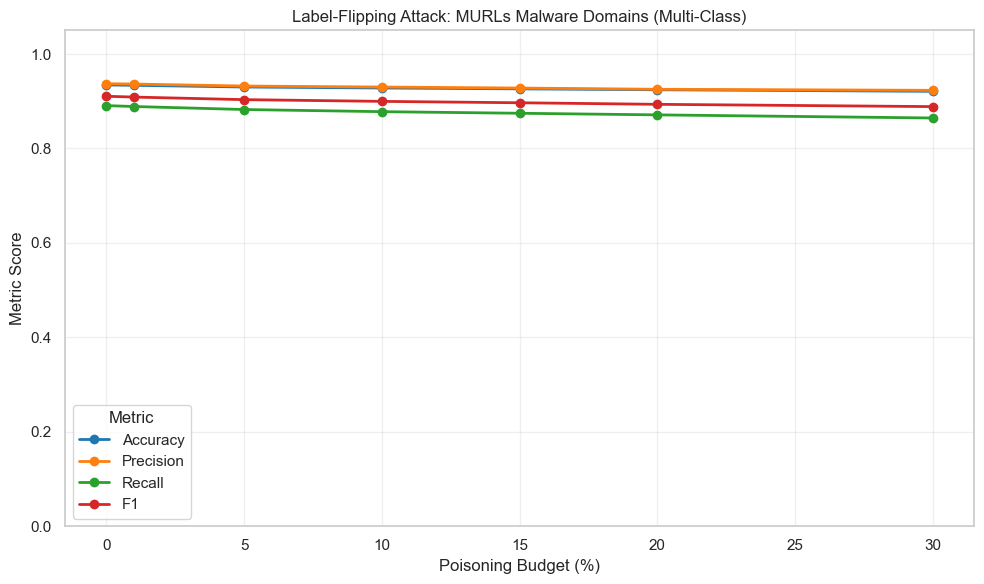

In [28]:
def plot_poisoning_degradation(
    df: pd.DataFrame,
    title: str,
    save_path=None,
) -> None:
    """Line plot: Poisoning Budget (%) vs metric scores."""
    fig, ax = plt.subplots(figsize=(10, 6))
    metrics_order = ["accuracy", "precision", "recall", "f1"]
    palette = sns.color_palette("tab10", n_colors=len(metrics_order))

    for metric, color in zip(metrics_order, palette):
        subset = df[df["metric"] == metric].sort_values("budget_pct")
        ax.plot(
            subset["budget_pct"],
            subset["score"],
            marker="o",
            linewidth=2,
            label=metric.capitalize(),
            color=color,
        )

    ax.set_xlabel("Poisoning Budget (%)")
    ax.set_ylabel("Metric Score")
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.legend(title="Metric", loc="best")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_poisoning_degradation(
    results_enron,
    title="Label-Flipping Attack: Enron Spam (Binary Classification)",
    save_path=Path("enron_poisoning_budget.png"),
)

plot_poisoning_degradation(
    results_MURLs,
    title="Label-Flipping Attack: MURLs Malware Domains (Multi-Class)",
    save_path=Path("MURLs_poisoning_budget.png"),
)